# **HADDOCK3 Protein–Peptide Small Benchmark**

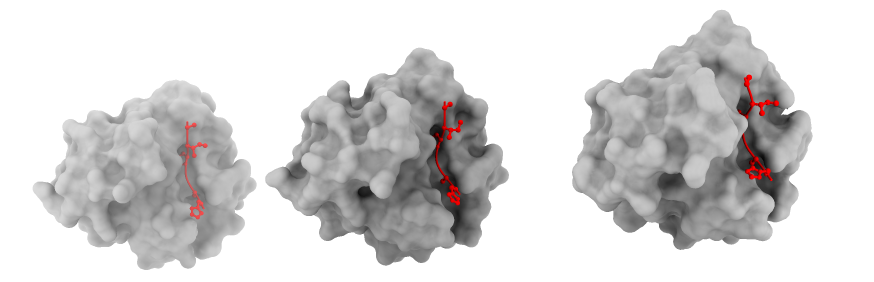

*Example protein–peptide complex, PDB-3AWR (peptide in red, receptor surface in grey).*

## Introduction

This tutorial demonstrates a benchmark workflow for docking of protein–peptide
complexes using HADDOCK3.

[HADDOCK3](https://github.com/haddocking/haddock3) is the latest, fully modular
version of HADDOCK (High Ambiguity Driven biomolecular DOCKing) — an
information-driven, integrative docki ng software developed by the
[BonvinLab](https://www.bonvinlab.org/) at Utrecht University. 
This notebook is part of the [HADDOCK3 benchmarking suite](https://github.com/haddocking/benchmarking),
a collection of curated docking benchmark datasets and scenarios (protein–protein,
protein–peptide, protein–glycan, and more).

This notebook runs a small mini-benchmark of multiple protein–peptide complexes
docked with HADDOCK3, orchestrated by
[haddock-runner](https://github.com/haddocking/haddock-runner) — the tool that reads
a benchmark scenario YAML, prepares and launches one HADDOCK3 run per complex, and
monitors them to completion.

The purpose of this notebook is not to reproduce the full protein–peptide benchmark.
Instead, it provides a compact **sanity/benchmarking** test to verify that the
HADDOCK3 protein–peptide workflow runs correctly end to end, from topology
generation to CAPRI-based evaluation, on a small subset of five complexes. Overall, this notebook walks through every step of the full reproduction pipeline —
install, dataset setup, run, and analysis — so it can be read as a complete,
self-contained overview of how to reproduce a HADDOCK3 protein–peptide benchmark
from scratch.



---
# **A brief introduction to HADDOCK3**

HADDOCK3 is the next generation integrative modelling software in the
long-lasting HADDOCK project. It represents a complete rethinking and rewriting
of the HADDOCK2.X series, implementing a new way to interact with HADDOCK and
offering new features to users who can now define custom workflows.

In the previous HADDOCK2.x versions, users had access to a highly
parameterisable yet rigid simulation pipeline composed of three steps:
`rigid-body docking (it0)`, `semi-flexible refinement (it1)`, and `final refinement (itw)`.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK2-stages.png">
</figure>

In HADDOCK3, users have the freedom to configure docking workflows into
functional pipelines by combining the different HADDOCK3 modules, thus
adapting the workflows to their projects. HADDOCK3 has therefore developed to
truthfully work like a puzzle of many pieces (simulation modules) that users combine freely. To this end, the old HADDOCK machinery has been modularized,
and several new modules added, including third-party software additions. As a
result, the modularization achieved in HADDOCK3 allows users to duplicate steps
within one workflow (e.g., to repeat twice the `it1` stage of the HADDOCK2.x
rigid workflow).

Note that, for simplification purposes, at this time, not all functionalities of
HADDOCK2.x have been ported to HADDOCK3, which does not (yet) support NMR RDC,
PCS and diffusion anisotropy restraints, cryo-EM restraints and coarse-graining.
Any type of information that can be converted into ambiguous interaction
restraints can, however, be used in HADDOCK3, which also supports the
*ab initio* docking modes of HADDOCK.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK3-workflow-scheme.png">
</figure>

To keep HADDOCK3 modules organized, we catalogued them into several
categories. However, there are no constraints on piping modules of different
categories.

The main module categories are "topology", "sampling", "refinement",
"scoring", and "analysis". There is no limit to how many modules can belong to a
category. Modules are added as developed, and new categories will be created
if/when needed. You can access the HADDOCK3 documentation page for the list of
all categories and modules. Below is a summary of the available modules:

* **Topology modules**
    * `topoaa`: *generates the all-atom topologies for the CNS engine.*
* **Sampling modules**
    * `rigidbody`: *Rigid body energy minimization with CNS (`it0` in haddock2.x).*
    * `lightdock`: *Third-party glow-worm swam optimization docking software.*
* **Model refinement modules**
    * `flexref`: *Semi-flexible refinement using a simulated annealing protocol through molecular dynamics simulations in torsion angle space (`it1` in haddock2.x).*
    * `emref`: *Refinement by energy minimisation (`itw` EM only in haddock2.4).*
    * `mdref`: *Refinement by a short molecular dynamics simulation in explicit solvent (`itw` in haddock2.X).*
* **Scoring modules**
    * `emscoring`: *scoring of a complex performing a short EM (builds the topology and all missing atoms).*
    * `mdscoring`: *scoring of a complex performing a short MD in explicit solvent + EM (builds the topology and all missing atoms).*
* **Analysis modules**
    * `alascan`: *Performs a systematic (or user-define) alanine scanning mutagenesis of interface residues.*
    * `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top-scoring model or reference structure if provided.*
    * `clustfcc`: *Clusters models based on the fraction of common contacts (FCC)*
    * `clustrmsd`: *Clusters models based on pairwise RMSD matrix calculated with the `rmsdmatrix` module.*
    * `contactmap`: *Generate contact matrices of both intra- and intermolecular contacts and a chordchart of intermolecular contacts.*
    * `rmsdmatrix`: *Calculates the pairwise RMSD matrix between all the models generated in the previous step.*
    * `ilrmsdmatrix`: *Calculates the pairwise interface-ligand-RMSD (il-RMSD) matrix between all the models generated in the previous step.*
    * `seletop`: *Selects the top N models from the previous step.*
    * `seletopclusts`: *Selects the top N clusters from the previous step.*

The HADDOCK3 workflows are defined in simple configuration text files, similar to the TOML format but with extra features.
Contrary to HADDOCK2.X which follows a rigid (yet highly parameterisable)
procedure, in HADDOCK3, you can create your own simulation workflows by
combining a multitude of independent modules that perform specialized tasks.

---
# **Software and data setup**

For reproducibility, this notebook uses pinned versions of the required software:
- **HADDOCK3:** `2026.8.0`, installed from PyPI
- **haddock-runner:** `4.1.0`, downloaded as a prebuilt binary from the corresponding GitHub release


In [ ]:
#@title 1. Install HADDOCK3 and haddock-runner
import os
import sys

# Pin versions for reproducibility
HADDOCK3_VERSION = "2026.8.0"
HADDOCK_RUNNER_TAG = "v4.1.0"

# Install HADDOCK3 in the current Jupyter kernel environment
!{sys.executable} -m pip install -q haddock3=={HADDOCK3_VERSION} pandas matplotlib

# Download the pinned haddock-runner release
TARGET = "x86_64-unknown-linux-musl"

ARCHIVE = f"haddock-runner-{HADDOCK_RUNNER_TAG}-{TARGET}.tar.gz"
URL = f"https://github.com/haddocking/haddock-runner/releases/download/{HADDOCK_RUNNER_TAG}/{ARCHIVE}"

!wget -q "$URL" -O /tmp/haddock-runner.tar.gz
!tar -xzf /tmp/haddock-runner.tar.gz -C /tmp
!mkdir -p ~/.local/bin
!cp /tmp/haddock-runner ~/.local/bin/haddock-runner
!chmod +x ~/.local/bin/haddock-runner

os.environ["PATH"] = f"{os.path.expanduser('~')}/.local/bin:{os.environ['PATH']}"

print("HADDOCK3:")
!haddock3 --version

print("\nhaddock-runner:")
!haddock-runner --version

In [ ]:
#@title 2. Download the benchmarking repository
from pathlib import Path

BASE_DIR = Path.cwd()
BENCHMARK_DIR = BASE_DIR / "benchmarking"

if not BENCHMARK_DIR.exists():
    !git clone --depth 1 https://github.com/haddocking/benchmarking.git "$BENCHMARK_DIR"
else:
    print(f"{BENCHMARK_DIR} already exists; using the existing checkout.")

PP_DIR = BENCHMARK_DIR / "docking_benchmarks" / "protein_peptide"
print("Protein-peptide benchmark directory:", PP_DIR)

print("\nContents:")
!ls -la "$PP_DIR"

## Preparing the protein–peptide dataset

This step clones the `haddocking/protein-peptide` dataset repo into
`protein-peptide-dataset/`. This repo holds the 98 protein–peptide complexes used
for the docking benchmark — this notebook only uses 5 of them, since it's meant as
a quick end-to-end sanity test rather than a full benchmark run.

We don't need the full 98-complex input list `setup.sh` builds. Cell 4 below writes
a much smaller version for just our five test complexes.

In [ ]:
#@title 3. Download the protein–peptide dataset
DATASET_DIR = PP_DIR / "protein-peptide-dataset"

if not DATASET_DIR.exists():
    !git clone -q https://github.com/haddocking/protein-peptide.git "$DATASET_DIR"

print("Dataset ready at:", DATASET_DIR)


In [ ]:
#@title 4. Create the five-complex test input list
TEST_INPUT = PP_DIR / "protein-peptide-input-test.txt"
complexes = ["1AWR", "1CE1", "1CKA", "1CZY", "1D4T"]
SUFFIXES = ("_r_u.pdb", "_l_u.pdb", "_b_ambig.tbl", "_target.pdb")

# One line per input file (not per PDB code): haddock-runner groups lines by
# their parent folder name to build one HADDOCK3 run per complex.
lines = []
for pdb_id in complexes:
    complex_dir = DATASET_DIR / pdb_id
    for f in sorted(complex_dir.glob(f"{pdb_id}_*")):
        if f.name.endswith(SUFFIXES):
            lines.append(str(f.relative_to(BENCHMARK_DIR)))

TEST_INPUT.write_text("\n".join(lines) + "\n")
print(f"protein-peptide-input-test.txt written with {len(lines)} file entries for {len(complexes)} complexes.")

# **Inspecting the small benchmark input**

`protein-peptide-input-test.txt` is the exact small input list this notebook uses,
built above for just the five test complexes (the repository's own copy of
this file, checked into version control, covers the same five complexes and would
contain identical entries).

**Format:** this is a plain text file with **one input file path per line**.
`haddock-runner` reads every line, groups the files by their parent folder
name (the PDB code), and starts one HADDOCK3 run per group. A target with
no lines in this file, or with lines pointing at files that don't exist,
simply won't get a run.

It contains files belonging to five systems:

- `1AWR`
- `1CE1`
- `1CKA`
- `1CZY`
- `1D4T`

The filename conventions are:

- `_r_u.pdb`: unbound receptor
- `_l_u.pdb`: unbound peptide ensemble
- `_b_ambig.tbl`: AIR restraints derived from the bound interface
- `_target.pdb`: reference/native complex used by `caprieval`

So a well-formed test file looks like this:

```
docking_benchmarks/protein_peptide/protein-peptide-dataset/1AWR/1AWR_r_u.pdb
docking_benchmarks/protein_peptide/protein-peptide-dataset/1AWR/1AWR_l_u.pdb
docking_benchmarks/protein_peptide/protein-peptide-dataset/1AWR/1AWR_b_ambig.tbl
docking_benchmarks/protein_peptide/protein-peptide-dataset/1AWR/1AWR_target.pdb
```

The test file isn't passed to `haddock-runner` directly — it's referenced by name from
the `general.input_list` key of the scenario YAML:

```yaml
general:
  input_list: protein-peptide-input-test.txt
  work_dir: benchmark_output/unbound_true_interface-test
```



In [ ]:
#@title 5. Show the exact protein-peptide-input-test.txt file
print(TEST_INPUT.read_text())

---
# **Inspecting the benchmark scenario**

The test YAML is already part of the benchmarking repository. We use it unchanged.

Important parameters include:

```yaml
general:
  input_list: protein-peptide-input-test.txt
  work_dir: benchmark_output/unbound_true_interface-test
  execution: local
  ncores: 4
  max_concurrent: 1
  mol_suffixes:
    - _r_u
    - _l_u              # multi-model peptide ensemble, sampled automatically

scenarios:
  - name: run-unbound-true_interface-test
    workflow:
        topoaa:

        rigidbody:
          sampling: 30
          ambig_fname: _b_ambig.tbl

        caprieval.1:
          reference_fname: _target.pdb

        seletop:
          select: 4

        caprieval.2:
          reference_fname: _target.pdb

        flexref:
          tolerance: 25
          ambig_fname: _b_ambig.tbl

        caprieval.3:
          reference_fname: _target.pdb

        emref:
          ambig_fname: _b_ambig.tbl

        caprieval.4:
          reference_fname: _target.pdb

        clustfcc:

        seletopclusts:

        caprieval.5:
          reference_fname: _target.pdb
```

This makes the notebook suitable as a small functional benchmark rather than a
full production-scale run. 

---
# **Running the benchmark**

`haddock-runner` reads the YAML, groups the files belonging to each target,
creates one HADDOCK3 run per system, and executes the test locally. 
The output directory defined by the YAML is:
`benchmark_output/unbound_true_interface-test`

Because the YAML uses paths relative to the protein–peptide benchmark directory,
we execute the runner from that directory (`cwd=BENCHMARK_DIR`, since
`docking_benchmarks/protein_peptide/...` is itself relative to the repo root).

In [ ]:
#@title 6. Run the five-complex HADDOCK3 protein–peptide mini benchmark
import subprocess
import re

cmd = [
    "haddock-runner",
    "docking_benchmarks/protein_peptide/"
    "unbound_true_interface_act-pass-test.yaml",
]

process = subprocess.Popen(
    cmd,
    cwd=BENCHMARK_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

ansi_escape = re.compile(r"\x1b\[[0-9;]*m")
all_lines = []

for line in process.stdout:
    clean_line = ansi_escape.sub("", line).rstrip()
    all_lines.append(clean_line)

    # Keep the live log readable, but don't let this filter hide a failure:
    # every line is still kept in `all_lines` and printed in full below if
    # haddock-runner exits with an error.
    if "[INFO]" in clean_line:
        print(clean_line)

returncode = process.wait()

if returncode != 0:
    print("\nhaddock-runner failed. Full log (including non-[INFO] lines):\n")
    print("\n".join(all_lines))
    raise subprocess.CalledProcessError(returncode, cmd)
else:
    print("\nhaddock-runner completed successfully for all targets.")

---
# **Inspecting the benchmark outputs**

HADDOCK3 + `haddock-runner` benchmark analysis happens at two levels:

1. **Per-run analysis (automatic).** Every `caprieval` step in the workflow already
   writes its own `N_caprieval_analysis/` folder inside each target's `run1/`
   directory, containing `capri_ss.tsv` (the raw per-model CAPRI metrics table) and an
   HTML report (`report.html`) with per-metric plots. Because the scenario sets
   `gen_archive: true`, this whole `run1/` directory is archived away as
   `run1_analysis.tgz` (plus a `run1.tgz` of the full run).
2. **Benchmark-wide analysis (manual, run once all targets finish).**
   `analysis/analysebenchmarkresults.py` aggregates the `capri_ss.tsv` files across
   every target and scenario, ranks models by HADDOCK score, and produces
   comparison plots and a JSON summary across the whole test set.

In [ ]:
#@title 7. Extract run1_analysis archives
import subprocess

OUTPUT_DIR = (
    PP_DIR
    / "benchmark_output"
    / "unbound_true_interface-test"
    / "run-unbound-true_interface-test"
)

targets = ["1AWR", "1CE1", "1CKA", "1CZY", "1D4T"]

extracted, failed = [], []
for target in targets:
    target_dir = OUTPUT_DIR / target
    archive = target_dir / "run1_analysis.tgz"

    if not archive.exists():
        print(f"Skipping {target}: {archive.name} not found (this target may have failed).")
        failed.append(target)
        continue

    print(f"Extracting {target}...")
    try:
        subprocess.run(["tar", "-xzf", str(archive)], cwd=target_dir, check=True)
        extracted.append(target)
    except subprocess.CalledProcessError as exc:
        print(f"Failed to extract {target}: {exc}")
        failed.append(target)

print(f"\nExtracted: {extracted}")
if failed:
    print(f"Not extracted (skipped): {failed}")

In [ ]:
#@title 8. Locate CAPRI result tables

capri_files = (
    sorted(OUTPUT_DIR.rglob("capri_ss.tsv"))
    if OUTPUT_DIR.exists()
    else []
)

print(f"Found {len(capri_files)} capri_ss.tsv files in total")
print("\nShowing results for 1AWR only:")

for f in capri_files:
    if "1AWR" in f.parts:
        print(f.relative_to(OUTPUT_DIR))

---
# **Inspecting the CAPRI result tables**

Once a HADDOCK3 run (or, here, a `haddock-runner` benchmark run) completes, the
resulting `run1/` directory contains the various steps (modules) of the defined
workflow numbered sequentially, e.g.:

```
> ls run1/
  00_topoaa
  01_rigidbody
  02_caprieval
  03_seletop
  04_flexref
  05_caprieval
  ...
  analysis
  data
  log
  traceback
```

Besides the numbered module directories, a run also contains:

* the `data` directory, containing the input data (PDB and restraint files) for the
  various modules
* the `analysis` directory, containing plots to visualise the results of each
  `caprieval` step
* the `traceback` directory, containing the names of the generated models for each
  step, so that a model can be traced back throughout the various stages

The simplest way to extract ranking information and the corresponding HADDOCK scores
is to look at the `X_caprieval` directories. Each of these directories always contains
a `capri_ss.tsv` file, with the model names, rankings and statistics (score, i-RMSD,
Fnat, l-RMSD, ilRMSD and DockQ score), e.g. from a `flexref`-stage `caprieval`:

```
../07_flexref/flexref_127.pdb	-	1	-180.605	1.223	0.864	3.249	3.253	0.779	...
../07_flexref/flexref_92.pdb	-	2	-170.394	1.224	0.795	3.256	3.263	0.756	...
../07_flexref/flexref_226.pdb	-	3	-169.150	1.316	0.682	3.583	3.576	0.699	...
../07_flexref/flexref_44.pdb	-	4	-168.426	1.141	0.750	3.058	3.059	0.756	...
../07_flexref/flexref_159.pdb	-	5	-160.324	1.260	0.636	3.454	3.464	0.694	...
```
### Protein–peptide model quality criteria

The quality of a protein–peptide docking model is assessed according to the **CAPRI classification**, using **i-RMSD** and **DockQ** as quality metrics. Lower i-RMSD values and higher DockQ values indicate better agreement with the reference complex.

#### i-RMSD classification

| Quality | Range (Å) |
|---|---:|
| **High** | 0–0.5 |
| **Medium** | 0.5–1.0 |
| **Acceptable** | 1.0–2.0 |
| **Near-acceptable** | 2.0–3.0 |
| **Low** | ≥ 3.0 |

#### DockQ classification

| Quality | Range |
|---|---:|
| **High** | 0.895–1.0 |
| **Medium** | 0.71–0.895 |
| **Acceptable** | 0.43–0.71 |
| **Near-acceptable** | 0.35–0.43 |
| **Low** | < 0.35 |

These thresholds are used by the benchmarking analysis to assign protein–peptide docking models to the **High**, **Medium**, **Acceptable**, **Near-acceptable**, and **Low**  quality categories.

---

In [ ]:
#@title 9. Inspect the final CAPRI table for 1AWR
import pandas as pd


def final_capri_table_per_target(capri_files, output_dir):
    """Find the final caprieval table available for each target."""
    tables_by_stage = {}

    for f in capri_files:
        target = f.relative_to(output_dir).parts[0]
        stage = f.parent.name
        stage_num = int(stage.split("_", 1)[0])

        df = pd.read_csv(f, sep="\t")
        tables_by_stage.setdefault(target, {})[stage_num] = (stage, df)

    final_tables = {}
    for target, stages in tables_by_stage.items():
        final_stage_num = max(stages)
        final_tables[target] = stages[final_stage_num]

    return final_tables


tables = final_capri_table_per_target(capri_files, OUTPUT_DIR)

target = "1AWR"

cols_of_interest = [
    "model",
    "caprieval_rank",
    "score",
    "irmsd",
    "fnat",
    "lrmsd",
    "ilrmsd",
    "dockq",
]

if target not in tables:
    print(f"No CAPRI result found for {target}.")
else:
    stage_name, df = tables[target]

    print(f"Showing final CAPRI table for {target}")
    print(f"Final caprieval stage: {stage_name}")

    available_cols = [c for c in cols_of_interest if c in df.columns]

    display(df[available_cols] if available_cols else df)

---
# **Full benchmark-wide analysis (`analysebenchmarkresults.py`)**

`analysis/analysebenchmarkresults.py` (v2.0.0 in the current repository) expects a
`<benchmark_directory>/<scenario_name>/<PDBid>/run1/` layout — which is exactly what
`haddock-runner` produced above — and, when run with `--from-archive` (`-a`), reads
`capri_ss.tsv` directly out of each target's `run1_analysis.tgz` rather than requiring
a live `run1/` directory (which, with `gen_archive: true`, never exists on disk).

For every scenario it ranks models by HADDOCK score and reports, at a series of
top-X thresholds, the fraction of targets whose best-ranked model reaches each CAPRI
quality class. Because this test only ever produces 30 rigid-body models per target,
the script's defaults don't fit our sampling size, so Cell 11 below patches **two**
module-level constants in the script before running it:

- `TOP_X_THRESHOLDS` — the top-X thresholds used for the bar/violin plots and the
  JSON summary. Default is `(1, 5, 10, 20, 50, 100, 200, 500, 1000)`; we shrink it to
  `(1, 5, 10, 15, 20, 25, 30)`.
- `MELQUIPLOT_NB_ENTRIES` — a **separate** constant (default `200`) that only
  controls how many top-ranked entries the melqui plot (`--melquiplots`) shows per
  target. It is not part of `TOP_X_THRESHOLDS`, so patching only that first constant
  silently leaves the melqui plot asking for a "top 200" that doesn't exist in a
  30-model run. We now patch this one too, down to `30`.

Key options used below:

- `-t peptide` — use the peptide-specific CAPRI thresholds (see table above) and the
  default `irmsd` metric.
- `-a` / `--from-archive` — read straight from the `run1_analysis.tgz` archives,
  since that's the only place the results live once `gen_archive: true` is set.
- `--custom-labels stage_labels.json` — give the auto-numbered `caprieval` stages
  (`02`, `04`, `06`, `08`, `11`) human-readable titles in the plots.
- `-o` — write the output figures/JSON into a dedicated `benchmark_analysis/`
  directory instead of the default `Analysis/` inside the benchmark output tree.
- `-q` / `--quiet` — silence the script's own banner and the `NN.NN %` progress
  lines it prints to stdout while generating each plot; only errors (and the
  figures/JSON summary) are shown.

Output files (see `analysis/README.md` for the full description):

| File | Contents |
|---|---|
| `*_capribarplots.png` | Stacked bar plots: fraction of targets reaching High / Medium / Acceptable quality at each top-X threshold, per pipeline stage |
| `*_performances.json` | The same information as machine-readable JSON |
| `*_benchmark_mapper.json` | Internal scenario/target/stage → file-path mapping |


In [ ]:
#@title 10. Create custom stage labels
import json

# Maps the auto-numbered caprieval stages of THIS scenario to readable titles.
# Stage order in unbound_true_interface_act-pass-test.yaml:
#   00 topoaa -> 01 rigidbody -> 02 caprieval.1 -> 03 seletop -> 04 caprieval.2
#   -> 05 flexref -> 06 caprieval.3 -> 07 emref -> 08 caprieval.4
#   -> 09 clustfcc -> 10 seletopclusts -> 11 caprieval.5
CUSTOM_LABELS = {
    "02": "Rigid-body docking",
    "04": "Top-4 selection (seletop)",
    "06": "Flexible refinement",
    "08": "Energy minimisation",
    "11": "Final clustered models",
}

LABELS_FILE = PP_DIR / "stage_labels.json"

with open(LABELS_FILE, "w") as f:
    json.dump(CUSTOM_LABELS, f, indent=4)

print(f"Wrote {LABELS_FILE}")

In [ ]:
#@title 11. Run the full benchmark-wide analysis and display figures
import re
import subprocess
import sys

from IPython.display import Image, display

RESULTS_DIR = PP_DIR / "benchmark_output" / "unbound_true_interface-test"
ANALYSIS_DIR = PP_DIR / "benchmark_analysis"
ANALYSIS_SCRIPT = BENCHMARK_DIR / "analysis" / "analysebenchmarkresults.py"

# This tiny test only ever produces 30 rigid-body models per target, so two of
# the script's module-level constants need shrinking before we run it:
#   - TOP_X_THRESHOLDS: default (1, 5, 10, 20, 50, 100, 200, 500, 1000) -- used
#     by the bar/violin plots and the JSON summary.
#   - MELQUIPLOT_NB_ENTRIES: default 200 -- a *separate* constant that only
#     controls the melqui plot's "top N" cutoff. It's easy to miss because it
#     isn't part of TOP_X_THRESHOLDS, so patching only that one still leaves
#     the melqui plot asking for a top-200 that can't exist in a 30-model run.
text = ANALYSIS_SCRIPT.read_text()
patched = re.sub(
    r"TOP_X_THRESHOLDS\s*=\s*\([^)]*\)",
    "TOP_X_THRESHOLDS = (1, 5, 10, 15, 20, 25, 30)",
    text,
)
patched = re.sub(
    r"MELQUIPLOT_NB_ENTRIES\s*=\s*\d+",
    "MELQUIPLOT_NB_ENTRIES = 30",
    patched,
)
if patched != text:
    ANALYSIS_SCRIPT.write_text(patched)

cmd = [
    sys.executable,
    str(ANALYSIS_SCRIPT),
    str(RESULTS_DIR),
    "--type", "peptide",
    "--from-archive",
    "--output_path", str(ANALYSIS_DIR),
    "--custom-labels", str(LABELS_FILE),
    "--per-scenario-plots",
    "--quiet",  # silence the script's banner + "NN.NN %" progress prints
]

result = subprocess.run(
    cmd,
    cwd=BENCHMARK_DIR,
    capture_output=True,
    text=True,
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    result.check_returncode()
elif result.stdout.strip():
    print(result.stdout)

figures = sorted(ANALYSIS_DIR.glob("*.png")) if ANALYSIS_DIR.exists() else []

if not figures:
    print(f"analysebenchmarkresults.py ran successfully but no .png figures were found in {ANALYSIS_DIR}.")
else:
    for fig in figures:
        print(fig.name)
        display(Image(filename=str(fig)))

json_summaries = sorted(ANALYSIS_DIR.glob("*_performances.json")) if ANALYSIS_DIR.exists() else []
if json_summaries:
    print("\nJSON performance summaries:")
    for j in json_summaries:
        print(" -", j)


---
# **Conclusions**

This notebook provides a reproducible, small-scale HADDOCK3 protein–peptide benchmark
using the exact test input and test scenario maintained in the official benchmarking
repository, following the same install → download-dataset → run → analyse flow as the
repository's own `setup.sh` / `run.sh` / `analyse.sh` scripts.

It should **not** be used to draw conclusions about full protein–peptide docking
performance, because the rigid-body sampling is intentionally reduced to only 30 models
(vs. 3000 in the full `unbound_true_interface_act-pass` scenario).

For production benchmarking, use the full protein–peptide scenarios from the
`haddocking/benchmarking` repository (`unbound_true_interface_act-pass`,
`unbound_abinitio-cm`, `unbound_ab_initio-ranair`, and their `-cltsel` variants) with
their full sampling settings, run via `./run.sh` and `./run-all.sh` from a local
checkout, ideally on a SLURM cluster.

The protein-peptide benchmark dataset and docking approach are described in:
Trellet M. et al. (2013). A unified conformational selection and induced fit approach to protein-peptide docking. PLOS ONE, 8(3), e58769. https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0058769